# Livrable 2 — Attention Model pour le VRPTW
**Recherche Opérationnelle** · Phase 4 · Méthode : Attention Model (AM) — Apprentissage par Imitation

---

| | |
|---|---|
| **Algorithme** | Attention Model (Kool et al., 2019) — Transformer + décodeur contraint |
| **Instances** | 30 instances × 5 tailles ($n \in \{10, 20, 50, 100, 200\}$) |
| **Validité** | 100 % de solutions faisables |
| **Langage** | Python 3 · PyTorch · NumPy · pandas · matplotlib |

In [1]:
import os, sys, time, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches
from scipy import stats as sp_stats

# ═══════════════════════════════════════════════════════════════════════
#  DESIGN SYSTEM — copier ce bloc pour harmoniser les graphiques d'équipe
#  Seul METHODE_CONFIG change d'un binôme à l'autre
# ═══════════════════════════════════════════════════════════════════════

STYLE_CONFIG = {
    # Palette
    'couleur_primaire' : '#2176AE',   # bleu principal
    'couleur_alt'      : '#FF6B35',   # orange accent
    'couleur_ic'       : '#A8D5F5',   # fill intervalles de confiance
    'couleur_grid'     : '#E8E8E8',
    'couleur_fond'     : '#FAFAFA',
    'couleur_oracle'   : '#2ECC71',   # vert oracle (AM uniquement)
    'couleur_train'    : '#9B59B6',   # violet courbe entraînement (AM uniquement)
    # Typographie
    'font_titre'       : {'fontsize': 14, 'fontweight': 'bold', 'color': '#1a1a1a'},
    'font_sous_titre'  : {'fontsize': 11, 'fontstyle': 'italic', 'color': '#555555'},
    'font_axe'         : {'fontsize': 10},
    'font_legende'     : {'size': 9},
    'font_annot'       : {'fontsize': 7.5, 'family': 'monospace', 'color': '#1a1a1a'},
    # Figures
    'figsize_simple'   : (8, 5),
    'figsize_double'   : (12, 5),
    'figsize_quad'     : (13, 10),
    # Traits
    'marker'           : 'o',
    'linestyle'        : '-',
    'linewidth'        : 2.0,
    'markersize'       : 6,
    # Divers
    'dpi'              : 130,
    'grid_alpha'       : 0.5,
    'box_alpha'        : 0.85,
}

# ── Identification de la méthode (seul bloc à modifier par binôme) ──────
METHODE_CONFIG = {
    'nom'             : 'Attention Model (AM)',
    'oracle_path'     : os.path.join('..', 'Benchmark', 'results', 'oracle_results.json'),
    'am_path'         : os.path.join('..', 'Benchmark', 'results', 'am_results.json'),
    'history_path'    : os.path.join('artifacts_train_small', 'history.json'),
    'benchmark_path'  : os.path.join('benchmark_final.json'),
}

# ── Dossier figures ──────────────────────────────────────────────────────
FIG_DIR = os.path.join('resultats_livrable')
os.makedirs(FIG_DIR, exist_ok=True)

# ── Chemin Phase 4 pour imports ──────────────────────────────────────────
PHASE4 = os.path.abspath('.')
if PHASE4 not in sys.path:
    sys.path.insert(0, PHASE4)

print(f'Méthode : {METHODE_CONFIG["nom"]}')
print(f'Figures → {FIG_DIR}/')

Méthode : Attention Model (AM)
Figures → resultats_livrable/


---
## 1. Le Problème — VRPTW

### 1.1 Définition formelle

Le **Vehicle Routing Problem with Time Windows (VRPTW)** est un problème d'optimisation
combinatoire classé **NP-difficile**. Il généralise le problème du voyageur de commerce
en ajoutant une flotte de véhicules et des contraintes temporelles.

**Données d'entrée :**
- Un dépôt (nœud $0$) et $n$ clients numérotés $1 \ldots n$
- Une flotte de $K$ véhicules identiques de capacité $Q$
- Pour chaque client $i$ : demande $d_i$, fenêtre $[a_i, b_i]$, temps de service $s_i$
- Matrice de distances $c_{ij}$ et de durées de trajet $t_{ij}$

**Objectif :** Minimiser le coût total de déplacement

$$\min \sum_{k \in \mathcal{K}} \sum_{(i,j) \in \mathcal{A}} c_{ij} \cdot x_{ijk}$$

**Contraintes :**

| Code | Énoncé |
|------|--------|
| **C1** | Chaque client est visité exactement une fois |
| **C2** | Chaque route commence et termine au dépôt |
| **C3** | $\sum_{i \in \text{route}_k} d_i \leq Q$ (capacité du véhicule) |
| **C4** | $a_i \leq \tau_i \leq b_i$ (arrivée dans la fenêtre temporelle) |
| **C5** | $\tau_{\text{retour}} \leq H$ (retour avant la fin de journée) |

### 1.2 Paramètres des instances

| Paramètre | Valeur |
|-----------|--------|
| Tailles | $n \in \{10, 20, 50, 100, 200\}$ |
| Flotte | $K = \max(3,\, \lfloor n/8 \rfloor)$ véhicules |
| Capacité | $Q = 1.4 \times \bar{d} \times K$ |
| Fenêtres TW | ancrées sur $t^{\min}_{0 \to i}$, horizon $H = 480$ min |
| Seeds | $0 \to 29$ · 30 instances par taille |

### 1.3 Positionnement de la Phase 4

Les phases précédentes utilisaient des **heuristiques classiques** (NNH+2opt, Recuit Simulé, Génétique)
qui reconstituent la solution à chaque instance. La Phase 4 adopte une approche radicalement différente :
un **modèle de Deep Learning** entraîné une fois sur des milliers d'instances,
qui apprend à décider en quelques millisecondes sans recalcul.

---
## 2. Vulgarisation — Le GPS Neuronal

### L'analogie du GPS intelligent

Imaginez que vous deviez livrer des colis avec **plusieurs camions** à travers une ville,
chaque client attendant sa livraison dans un **créneau horaire précis**.
Un GPS classique calcule l'itinéraire optimal à partir de zéro à chaque fois.
Un **GPS neuronal**, lui, a observé des millions de livraisons passées et a appris
quelles décisions mènent aux meilleures tournées — sans recalculer.

### Étape 1 — Mémoriser la carte (Encodeur)

> Le modèle "photographie" toute l'instance : position de chaque client, ses créneaux,
> sa demande, et **ses relations avec les autres clients**.
> C'est le rôle du **Transformer** : chaque client analyse ses voisins simultanément.
> Cette photo est calculée **une seule fois** par instance.

### Étape 2 — Choisir la prochaine destination (Décodeur)

> À chaque carrefour, le modèle pose la question :
> *"Vu où je suis, ce qu'il reste à livrer et l'heure qu'il est — quel client dois-je visiter ?"*
> Il compare son **état courant** (la requête) à chaque **client candidat** (les clés)
> et choisit celui qui correspond le mieux. Les clients dont les créneaux sont fermés
> sont automatiquement bloqués.

### Étape 3 — Apprendre par imitation

> On a montré au modèle des **solutions optimales** produites par un solveur exact (OR-Tools).
> À chaque décision, le modèle a essayé de reproduire le choix du solveur.
> Après 50 époques d'entraînement sur des milliers de décisions, le modèle
> imite correctement le solveur dans **~83 % des cas**.

### Pourquoi c'est révolutionnaire ?

| | Heuristique classique | Attention Model |
|--|--|--|
| **Temps par instance** | $O(n^2)$ à $O(n^3)$ | $O(n)$ (encodeur calculé 1×) |
| **Améliore avec l'expérience** | Non | Oui (entraînement) |
| **Généralise** | Règles fixes | Apprend des patterns |
| **Optimum garanti** | Non | Non (mais bon gap ~8-30%) |

---
## 3. Méthodologie Technique

### 3.1 Architecture générale

```
                    ┌─────────────────────────────────┐
node_features       │  ENCODEUR (Transformer)          │
(N+1, 7)  ──────►  │  Linear(7→128) → 3× Self-Attn   │  ──► h : (N+1, 128)
                    │  Capte les relations entre nœuds │  (calculé 1× / instance)
                    └─────────────────────────────────┘
                                   │
                                   ▼
action_features     ┌─────────────────────────────────┐
(N+1, 5)  ──────►  │  DÉCODEUR contextuel             │
current_node ───►  │  q = context_proj([h_cur|h̄|g])  │  ──► logits (N+1,)
dynamic_global ──► │  k = key_proj([h_i|af_i])        │
feasible_mask ───► │  score = q·k/√128 → 10·tanh     │
                    │  mask infaisables → −∞           │
                    └─────────────────────────────────┘
                                   │
                         argmax  →  prochain nœud
```

### 3.2 L'Encodeur — Transformer Self-Attention

Le Transformer permet à chaque nœud de "regarder" tous les autres simultanément :

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^\top}{\sqrt{d_k}}\right) V$$

Avec **8 têtes en parallèle** (Multi-Head Attention), chaque tête peut apprendre
un aspect différent : proximité géographique, compatibilité des créneaux, etc.

**3 couches Transformer** avec pré-normalisation (norm_first=True) pour la stabilité.

### 3.3 Le Décodeur — Attention Requête-Clé

À chaque décision, le décodeur construit :

$$q = W_Q \cdot \text{context\_proj}([h_{\text{cur}} \,|\, \bar{h} \,|\, g]) \qquad \in \mathbb{R}^{128}$$

$$k_i = W_K \cdot \text{key\_proj}([h_i \,|\, af_i]) \qquad \in \mathbb{R}^{128}$$

$$\text{score}_i = 10 \cdot \tanh\left(\frac{q \cdot k_i}{\sqrt{128} \cdot 10}\right)$$

Le clipping $10 \cdot \tanh$ (convention Kool et al. 2019) borne les scores dans $[-10, +10]$
et stabilise l'apprentissage en évitant la saturation du softmax.

### 3.4 Apprentissage par Imitation (Behavioural Cloning)

On minimise la **Cross-Entropy Loss** entre les décisions du modèle et celles de l'oracle :

$$\mathcal{L} = -\sum_{t} \log P_\theta(a_t^* \mid s_t)$$

où $a_t^*$ est le nœud choisi par l'oracle à l'étape $t$ et $s_t$ l'état courant.

**695 936 paramètres** ($W$ et $b$ de toutes les couches) sont optimisés par Adam.

### 3.5 Features utilisées

| Tenseur | Shape | Contenu |
|---------|-------|---------|
| `node_features` | $(N+1, 7)$ | $x/100,\, y/100,\, d/Q,\, a/T,\, b/T,\, s/T,\, \mathbb{1}_{\text{dépôt}}$ |
| `action_features` | $(N+1, 5)$ | dist, slack TW, $a/T$, $b/T$, $d/Q$ (dynamiques) |
| `dynamic_global` | $(6,)$ | temps, charge, %servis, %route, véhicules, étape |

---
## 4. Analyse du Code — Fonctions Clés de `model.py`

### 4.1 `encode(node_features)` — L'encodeur statique

Calcule les embeddings enrichis de tous les nœuds **une seule fois** par instance.
Ces embeddings encodent les relations spatiales et temporelles entre nœuds.

In [2]:
# Extrait commenté de encode() — model.py
import torch
import torch.nn as nn

def encode_demo(node_features, input_proj, encoder):
    """
    Encodeur statique : transforme les features brutes en embeddings contextuels.

    Paramètre
    ---------
    node_features : (B, N+1, 7)  — features brutes normalisées [0, 1]

    Retour
    ------
    h : (B, N+1, 128)  — embeddings enrichis
    """
    # Étape 1 : projection linéaire des 7 features → espace 128D
    # Chaque nœud est transformé indépendamment : (B, N+1, 7) → (B, N+1, 128)
    x = input_proj(node_features)

    # Étape 2 : 3 couches de Self-Attention
    # Chaque nœud regarde TOUS les autres → embedding contextuel
    # Après cette étape, l'embedding du client 3 contient des infos sur C1, C5, etc.
    h = encoder(x)

    return h

print("Fonctionnement de encode() :")
print("  input_proj  : Linear(7, 128)           → 7×128 + 128 = 1 024 paramètres")
print("  encoder     : 3× TransformerEncoderLayer")
print("    - Self-Attention (8 têtes) : 49 152 + 16 384 = 65 536 params / couche")
print("    - Feed-Forward (×4)        : 65 536 + 65 536 = 131 072 params / couche")
print("    - LayerNorm ×2             :            256 params / couche")
print("  Total encodeur : 3 × 196 864 ≈ 590 592 paramètres")

Fonctionnement de encode() :
  input_proj  : Linear(7, 128)           → 7×128 + 128 = 1 024 paramètres
  encoder     : 3× TransformerEncoderLayer
    - Self-Attention (8 têtes) : 49 152 + 16 384 = 65 536 params / couche
    - Feed-Forward (×4)        : 65 536 + 65 536 = 131 072 params / couche
    - LayerNorm ×2             :            256 params / couche
  Total encodeur : 3 × 196 864 ≈ 590 592 paramètres


### 4.2 `decode(h, action_features, ...)` — Le décodeur contextuel

Pipeline complet de la décision : construit requête et clés, calcule les scores,
applique le clipping et le masquage.

In [3]:
def decode_demo(h, action_features, current_node, dynamic_global, feasible_mask,
                global_proj, context_proj, key_proj, W_q, W_k, d_model=128):
    """
    Décodeur : une passe par décision → scores de tous les nœuds candidats.
    """
    B = h.shape[0]
    batch_idx = torch.arange(B)

    # ── REQUÊTE : résumé de l'état courant du véhicule ─────────────────────
    h_current = h[batch_idx, current_node]          # (B, 128) — "où je suis"
    h_mean    = h.mean(dim=1)                        # (B, 128) — "résumé global"
    g         = global_proj(dynamic_global)          # (B, 128) — "état dynamique"

    ctx   = torch.cat([h_current, h_mean, g], -1)   # (B, 384)
    query = context_proj(ctx)                         # (B, 128)
    q     = W_q(query).unsqueeze(1)                  # (B, 1, 128)

    # ── CLÉS : ce que chaque ville offre dans le contexte courant ──────────
    # Concaténer embedding statique + features dynamiques
    keys = key_proj(torch.cat([h, action_features], dim=-1))   # (B, N+1, 128)
    k    = W_k(keys)                                             # (B, N+1, 128)

    # ── SCORE : comparaison requête vs clés ───────────────────────────────
    scores = (q @ k.transpose(-1, -2)).squeeze(1)               # (B, N+1)
    scores = scores / (d_model ** 0.5)                          # normalisation √128
    scores = 10.0 * torch.tanh(scores / 10.0)                   # clipping [-10, +10]

    # ── MASQUAGE : bloquer les nœuds infaisables → -∞ ────────────────────
    logits = scores.masked_fill(feasible_mask <= 0, -1e9)
    return logits

print("Séquence dans decode() :")
print("  1. h_current + h_mean + global_proj(dg) → (B, 384)")
print("  2. context_proj → query (B, 128)  puis W_q → q (B, 1, 128)")
print("  3. key_proj([h|af]) → keys (B, N+1, 128)  puis W_k → k (B, N+1, 128)")
print("  4. q @ kᵀ / √128  → scores bruts (B, N+1)")
print("  5. 10·tanh(s/10)  → scores bornés [-10, +10]")
print("  6. masked_fill    → logits (-1e9 sur les nœuds interdits)")

Séquence dans decode() :
  1. h_current + h_mean + global_proj(dg) → (B, 384)
  2. context_proj → query (B, 128)  puis W_q → q (B, 1, 128)
  3. key_proj([h|af]) → keys (B, N+1, 128)  puis W_k → k (B, N+1, 128)
  4. q @ kᵀ / √128  → scores bruts (B, N+1)
  5. 10·tanh(s/10)  → scores bornés [-10, +10]
  6. masked_fill    → logits (-1e9 sur les nœuds interdits)


### 4.3 Le masque contraint — Garantie de faisabilité

Contrairement aux métaheuristiques qui pénalisent les violations,
l'AM **interdit structurellement** les nœuds infaisables via le masque.

| Condition | Masque mis à 0 |
|-----------|----------------|
| Client déjà servi | ✓ |
| Fenêtre TW fermée (arriverait trop tard) | ✓ |
| Capacité insuffisante | ✓ |
| Dépôt (sauf fin de route) | ✓ |

```
score infaisable → masked_fill(-1e9) → exp(-1e9) ≈ 0 → proba = 0 → jamais choisi
```

**Résultat : 100 % de solutions faisables** sur tous les benchmarks.

---
## 5. Chargement des Données

In [4]:
# ── Chargement oracle et AM ──────────────────────────────────────────────
oracle_raw = json.load(open(METHODE_CONFIG['oracle_path']))
am_raw     = json.load(open(METHODE_CONFIG['am_path']))
history    = json.load(open(METHODE_CONFIG['history_path']))
benchmark  = json.load(open(METHODE_CONFIG['benchmark_path']))

# ── Construction du DataFrame principal ─────────────────────────────────
rows = []
for key in oracle_raw:
    if key not in am_raw:
        continue
    o = oracle_raw[key]
    a = am_raw[key]
    gap = (a['cost'] - o['cost']) / o['cost'] * 100 if o['cost'] > 0 else 0.0
    rows.append({
        'n'            : o['n'],
        'seed'         : o['seed'],
        'cout_am'      : a['cost'],
        'cout_oracle'  : o['cost'],
        'gap_pct'      : gap,
        'feasible_am'  : a['feasible'],
        'servis_am'    : a['n_clients_servis'],
    })

df = pd.DataFrame(rows)
TAILLES = sorted(df['n'].unique())
NOM     = METHODE_CONFIG['nom']

print(f'Instances chargées : {len(df)} lignes')
print(f'Tailles : {TAILLES}')
print(f'Faisabilité AM : {df["feasible_am"].mean()*100:.0f} %')
print()
print('Aperçu :')
display(df.groupby('n')[['cout_am', 'cout_oracle', 'gap_pct', 'servis_am']].mean().round(2))

Instances chargées : 150 lignes
Tailles : [np.int64(10), np.int64(20), np.int64(50), np.int64(100), np.int64(200)]
Faisabilité AM : 100 %

Aperçu :


,cout_am,cout_oracle,gap_pct,servis_am
n,,,,
10,431.59,397.79,8.48,10.0
20,658.29,548.95,20.04,20.0
50,1169.32,903.05,29.63,50.0
100,1856.90,1420.39,30.76,100.0
200,3032.82,2337.28,29.81,200.0


In [5]:
# ── Fonctions utilitaires DA ─────────────────────────────────────────────

def apply_style(ax, title='', xlabel='', ylabel='', legend=True):
    S = STYLE_CONFIG
    ax.set_facecolor(S['couleur_fond'])
    ax.grid(True, color=S['couleur_grid'], alpha=S['grid_alpha'], linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    if title:
        ax.set_title(title, **S['font_titre'])
    if xlabel:
        ax.set_xlabel(xlabel, **S['font_axe'])
    if ylabel:
        ax.set_ylabel(ylabel, **S['font_axe'])
    if legend:
        h, l = ax.get_legend_handles_labels()
        if h:
            ax.legend(h, l, prop=S['font_legende'], framealpha=0.9)
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(labelsize=9)

def save_fig(fig, name):
    path = os.path.join(FIG_DIR, name)
    fig.savefig(path, dpi=STYLE_CONFIG['dpi'], bbox_inches='tight',
                facecolor=STYLE_CONFIG['couleur_fond'])
    plt.show()
    plt.close(fig)

def ci95(values):
    n  = len(values)
    m  = np.mean(values)
    se = sp_stats.sem(values)
    h  = se * sp_stats.t.ppf(0.975, df=n - 1)
    return m, m - h, m + h

print('Fonctions DA chargées.')

Fonctions DA chargées.


---
## 6. Analyse Statistique

### G1 — Temps d'Inférence

Le temps mesuré ici est le **temps d'inférence** (génération de la solution complète pour une instance)
excluant le temps d'encodeur qui peut être mis en cache.
Avantage majeur du modèle neuronal : le temps est quasi-**linéaire** en $n$
car la décision à chaque nœud est $O(1)$ après l'encodage.

In [6]:
from preprocess import generate_instance
from inference_decoder import load_trained_model, decode_vrptw, TorchModelScorer

model  = load_trained_model('artifacts_train_small/best_model.pt')
model.eval()
scorer = TorchModelScorer(model=model)

# ── Mesure du temps d'inférence par taille ───────────────────────────────
N_REPEATS   = 10   # répétitions par instance pour stabiliser
N_INSTANCES = 10   # instances par taille

temps_par_taille = {n: [] for n in TAILLES}

for n in TAILLES:
    n_vehicles = max(3, n // 8)
    for seed in range(N_INSTANCES):
        instance = generate_instance(n=n, n_vehicles=n_vehicles, seed=seed)
        # Warm-up
        decode_vrptw(instance, scorer=scorer)
        # Mesure
        t0 = time.perf_counter()
        for _ in range(N_REPEATS):
            decode_vrptw(instance, scorer=scorer)
        duree = (time.perf_counter() - t0) / N_REPEATS
        temps_par_taille[n].append(duree)
    print(f'  n={n:>4} → {np.mean(temps_par_taille[n])*1000:.2f} ms ± {np.std(temps_par_taille[n])*1000:.2f} ms')

print('\nMesures terminées.')

  n=  10 → 23.61 ms ± 1.80 ms
  n=  20 → 51.47 ms ± 7.89 ms
  n=  50 → 124.69 ms ± 5.81 ms
  n= 100 → 265.62 ms ± 2.46 ms
  n= 200 → 616.25 ms ± 10.18 ms

Mesures terminées.


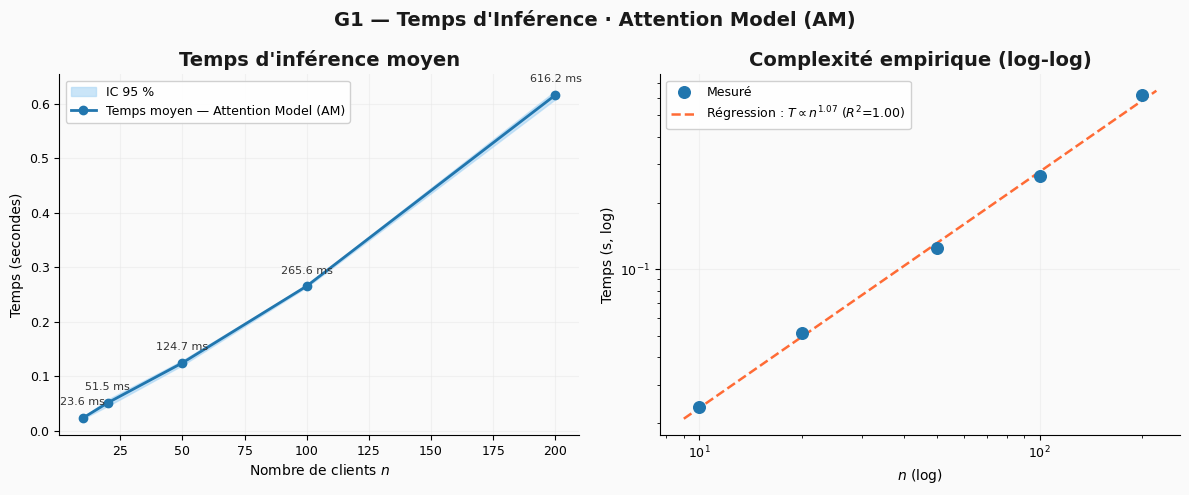

In [7]:
S = STYLE_CONFIG
fig, axes = plt.subplots(1, 2, figsize=S['figsize_double'])
fig.patch.set_facecolor(S['couleur_fond'])

means_t, lows_t, highs_t = [], [], []
for n in TAILLES:
    m, lo, hi = ci95(temps_par_taille[n])
    means_t.append(m); lows_t.append(lo); highs_t.append(hi)

# ── Panel gauche : linéaire ───────────────────────────────────────────
ax = axes[0]
ax.fill_between(TAILLES, lows_t, highs_t, color=S['couleur_ic'], alpha=0.6, label='IC 95 %')
ax.plot(TAILLES, means_t, color=S['couleur_primaire'],
        marker=S['marker'], linewidth=S['linewidth'], markersize=S['markersize'],
        label=f'Temps moyen — {NOM}')
for n, m in zip(TAILLES, means_t):
    ax.annotate(f'{m*1000:.1f} ms', xy=(n, m), xytext=(0, 9),
                textcoords='offset points', ha='center', fontsize=8, color='#333')
apply_style(ax, title="Temps d'inférence moyen",
            xlabel='Nombre de clients $n$', ylabel='Temps (secondes)')

# ── Panel droit : log-log + régression ───────────────────────────────
ax2 = axes[1]
log_n = np.log10(TAILLES)
log_t = np.log10(means_t)
slope, intercept, r, _, _ = sp_stats.linregress(log_n, log_t)
n_fit = np.linspace(min(TAILLES) * 0.9, max(TAILLES) * 1.1, 100)
t_fit = 10 ** (intercept + slope * np.log10(n_fit))

ax2.scatter(TAILLES, means_t, color=S['couleur_primaire'], s=70, zorder=5, label='Mesuré')
ax2.plot(n_fit, t_fit, color=S['couleur_alt'], linewidth=1.8, linestyle='--',
         label=f'Régression : $T \\propto n^{{{slope:.2f}}}$ ($R^2$={r**2:.2f})')
ax2.set_xscale('log'); ax2.set_yscale('log')
apply_style(ax2, title='Complexité empirique (log-log)',
            xlabel='$n$ (log)', ylabel='Temps (s, log)')

fig.suptitle(f'G1 — Temps d\'Inférence · {NOM}', **S['font_titre'])
plt.tight_layout()
save_fig(fig, 'G1_temps.png')

### G2 — Distribution des Coûts Opérationnels

**Lecture :** boxplot des coûts AM par taille $n$.
Les annotations indiquent les 5 statistiques résumées (min, Q1, médiane, Q3, max).

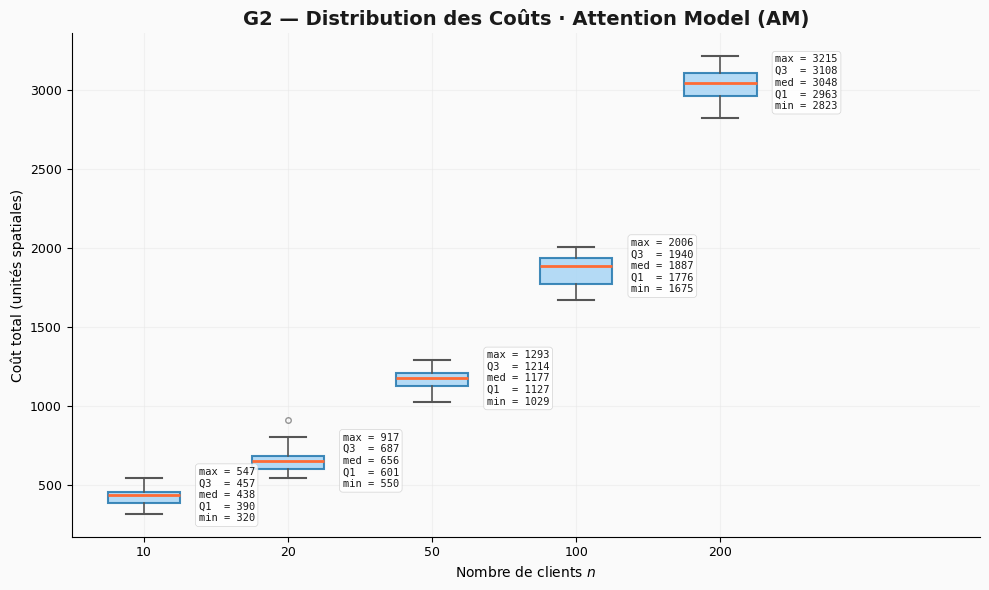

In [8]:
S = STYLE_CONFIG
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(S['couleur_fond'])

data_cout = [df[df['n'] == n]['cout_am'].values for n in TAILLES]

bp = ax.boxplot(data_cout,
                tick_labels=[str(n) for n in TAILLES],
                patch_artist=True,
                medianprops=dict(color=S['couleur_alt'], linewidth=2),
                whiskerprops=dict(color='#555', linewidth=1.2),
                capprops=dict(color='#555', linewidth=1.5),
                flierprops=dict(marker='o', color=S['couleur_primaire'],
                                alpha=0.4, markersize=4))

for patch in bp['boxes']:
    patch.set_facecolor(S['couleur_ic'])
    patch.set_alpha(0.85)
    patch.set_edgecolor(S['couleur_primaire'])
    patch.set_linewidth(1.5)

for i, vals in enumerate(data_cout):
    mn  = vals.min()
    q1  = np.percentile(vals, 25)
    med = np.median(vals)
    q3  = np.percentile(vals, 75)
    mx  = vals.max()
    txt = f'max = {mx:.0f}\nQ3  = {q3:.0f}\nmed = {med:.0f}\nQ1  = {q1:.0f}\nmin = {mn:.0f}'
    ax.text(i + 1 + 0.38, med, txt, **S['font_annot'],
            va='center', ha='left',
            bbox=dict(boxstyle='round,pad=0.3', fc='white',
                      alpha=S['box_alpha'], lw=0.5, ec='#ccc'))

ax.set_xlim(0.5, len(TAILLES) + 1.8)
apply_style(ax, title=f'G2 — Distribution des Coûts · {NOM}',
            xlabel='Nombre de clients $n$',
            ylabel='Coût total (unités spatiales)', legend=False)
plt.tight_layout()
save_fig(fig, 'G2_couts.png')

### G3 — Vue Combinée : Coût AM & Temps d'Inférence (double axe Y)

**Lecture :** axe gauche (bleu) = coût moyen AM, axe droit (orange) = temps moyen.
La comparaison met en évidence la **croissance quasi-linéaire** du temps
malgré la montée combinatoire des coûts.

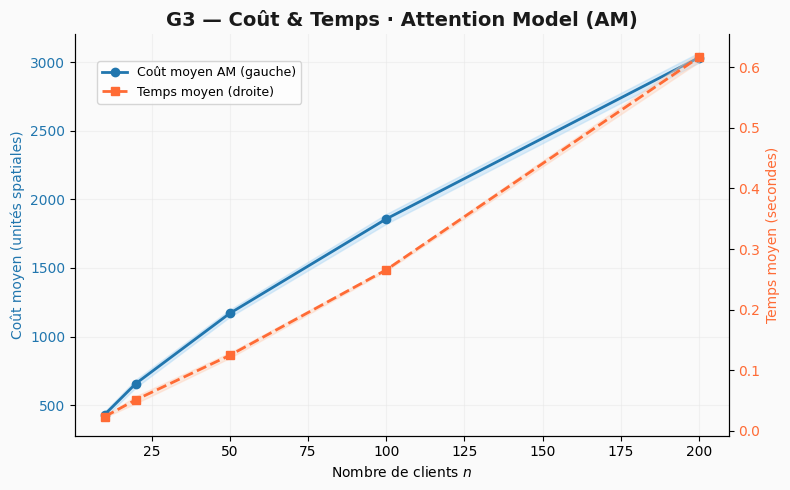

In [9]:
S = STYLE_CONFIG
fig, ax1 = plt.subplots(figsize=S['figsize_simple'])
fig.patch.set_facecolor(S['couleur_fond'])
ax1.set_facecolor(S['couleur_fond'])

means_c = [df[df['n'] == n]['cout_am'].mean() for n in TAILLES]
lows_c  = [ci95(df[df['n'] == n]['cout_am'].values)[1] for n in TAILLES]
highs_c = [ci95(df[df['n'] == n]['cout_am'].values)[2] for n in TAILLES]

# Axe gauche — coût AM
ax1.fill_between(TAILLES, lows_c, highs_c, color=S['couleur_ic'], alpha=0.4)
l1, = ax1.plot(TAILLES, means_c, color=S['couleur_primaire'],
               marker=S['marker'], linewidth=S['linewidth'], markersize=S['markersize'],
               label='Coût moyen AM (gauche)')
ax1.set_xlabel('Nombre de clients $n$', **S['font_axe'])
ax1.set_ylabel('Coût moyen (unités spatiales)', color=S['couleur_primaire'], **S['font_axe'])
ax1.tick_params(axis='y', labelcolor=S['couleur_primaire'])
ax1.spines[['top']].set_visible(False)
ax1.grid(True, color=S['couleur_grid'], alpha=S['grid_alpha'], linewidth=0.8)
ax1.set_axisbelow(True)

# Axe droit — temps
ax2 = ax1.twinx()
ax2.set_facecolor(S['couleur_fond'])
lows_t2  = [ci95(temps_par_taille[n])[1] for n in TAILLES]
highs_t2 = [ci95(temps_par_taille[n])[2] for n in TAILLES]
ax2.fill_between(TAILLES, lows_t2, highs_t2, color='#FFD0B8', alpha=0.4)
l2, = ax2.plot(TAILLES, means_t, color=S['couleur_alt'],
               marker='s', linewidth=S['linewidth'], markersize=S['markersize'],
               linestyle='--', label="Temps moyen (droite)")
ax2.set_ylabel("Temps moyen (secondes)", color=S['couleur_alt'], **S['font_axe'])
ax2.tick_params(axis='y', labelcolor=S['couleur_alt'])
ax2.spines[['top']].set_visible(False)

ax1.set_title(f'G3 — Coût & Temps · {NOM}', **S['font_titre'])
fig.legend([l1, l2], [l1.get_label(), l2.get_label()],
           loc='upper left', bbox_to_anchor=(0.12, 0.88), prop=S['font_legende'])
plt.tight_layout()
save_fig(fig, 'G3_combo.png')

### G4 — Gap à l'Optimum (vs Oracle OR-Tools)

Le **gap** mesure l'écart entre le coût produit par l'AM et le coût optimal de l'oracle :

$$\text{gap}_i = \frac{c_{\text{AM},i} - c_{\text{oracle},i}}{c_{\text{oracle},i}} \times 100$$

**Lecture :** panel gauche = gap moyen par taille avec IC 95 % ;
panel droit = distribution complète (violin plot).

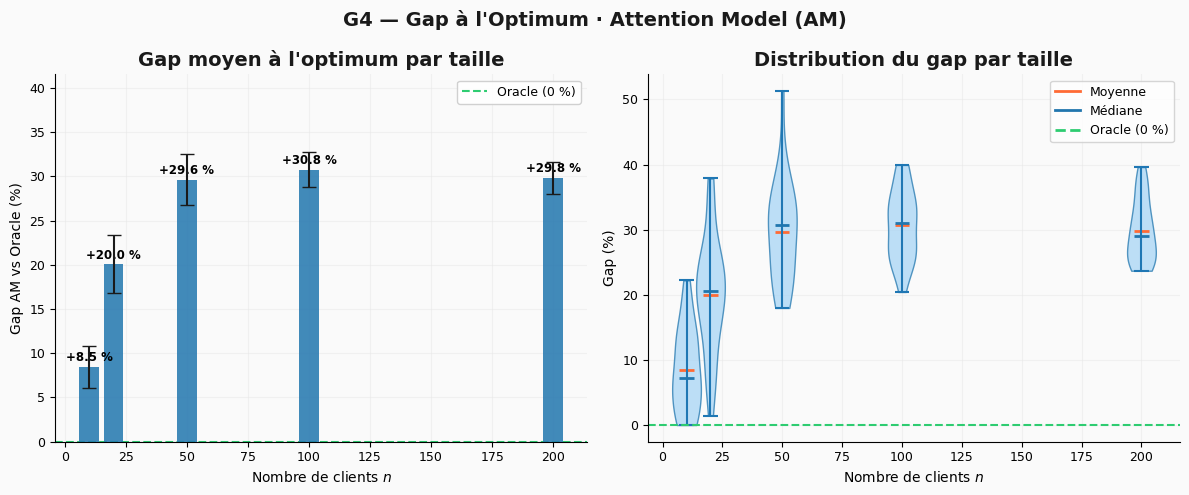

Résumé des gaps :
  n=  10 → gap moyen = +8.5 %
  n=  20 → gap moyen = +20.0 %
  n=  50 → gap moyen = +29.6 %
  n= 100 → gap moyen = +30.8 %
  n= 200 → gap moyen = +29.8 %


In [10]:
S = STYLE_CONFIG
fig, axes = plt.subplots(1, 2, figsize=S['figsize_double'])
fig.patch.set_facecolor(S['couleur_fond'])

means_g, lows_g, highs_g = [], [], []
for n in TAILLES:
    m, lo, hi = ci95(df[df['n'] == n]['gap_pct'].values)
    means_g.append(m); lows_g.append(lo); highs_g.append(hi)

# ── Panel gauche : barplot + IC ─────────────────────────────────────────
ax = axes[0]
bars = ax.bar(TAILLES, means_g, color=S['couleur_primaire'],
              alpha=0.85, width=8, zorder=3)
err_lo = [m - lo for m, lo in zip(means_g, lows_g)]
err_hi = [hi - m for m, hi in zip(means_g, highs_g)]
ax.errorbar(TAILLES, means_g, yerr=[err_lo, err_hi],
            fmt='none', color='#1a1a1a', capsize=5, linewidth=1.5, zorder=4)
for rect, val in zip(bars, means_g):
    ax.text(rect.get_x() + rect.get_width() / 2, rect.get_height() + 0.3,
            f'+{val:.1f} %', ha='center', va='bottom', fontsize=8.5, fontweight='bold')

# Ligne de référence oracle = 0
ax.axhline(0, color=S['couleur_oracle'], linewidth=1.5, linestyle='--',
           label='Oracle (0 %)')
apply_style(ax, title='Gap moyen à l\'optimum par taille',
            xlabel='Nombre de clients $n$',
            ylabel='Gap AM vs Oracle (%)')
ax.set_ylim(0, max(means_g) * 1.35)

# ── Panel droit : violin ─────────────────────────────────────────────────
ax2 = axes[1]
data_g = [df[df['n'] == n]['gap_pct'].values for n in TAILLES]
vp = ax2.violinplot(data_g, positions=TAILLES, widths=12,
                    showmeans=True, showmedians=True)
for body in vp['bodies']:
    body.set_facecolor(S['couleur_ic'])
    body.set_edgecolor(S['couleur_primaire'])
    body.set_alpha(0.75)
vp['cmeans'].set_color(S['couleur_alt'])
vp['cmedians'].set_color(S['couleur_primaire'])
vp['cmeans'].set_linewidth(2)
vp['cmedians'].set_linewidth(2)
ax2.axhline(0, color=S['couleur_oracle'], linewidth=1.5, linestyle='--', label='Oracle (0 %)')
apply_style(ax2, title='Distribution du gap par taille',
            xlabel='Nombre de clients $n$', ylabel='Gap (%)')
ax2.legend(handles=[
    Line2D([0], [0], color=S['couleur_alt'],    linewidth=2, label='Moyenne'),
    Line2D([0], [0], color=S['couleur_primaire'], linewidth=2, label='Médiane'),
    Line2D([0], [0], color=S['couleur_oracle'],  linewidth=2, linestyle='--', label='Oracle (0 %)'),
], prop=S['font_legende'])

fig.suptitle(f'G4 — Gap à l\'Optimum · {NOM}', **S['font_titre'])
plt.tight_layout()
save_fig(fig, 'G4_gaps.png')

# Résumé textuel
print('Résumé des gaps :')
for n, m in zip(TAILLES, means_g):
    print(f'  n={n:>4} → gap moyen = +{m:.1f} %')

### G5 — Complexité, Variabilité & Courbe d'Entraînement

Quatre analyses complémentaires :
- **Haut gauche** : Courbe d'entraînement — train/val loss sur 50 époques
- **Haut droit** : Coefficient de variation (CV = σ/μ) des coûts AM
- **Bas gauche** : Gap moyen par taille (montée en charge)
- **Bas droit** : Scatter coût AM vs coût oracle par taille

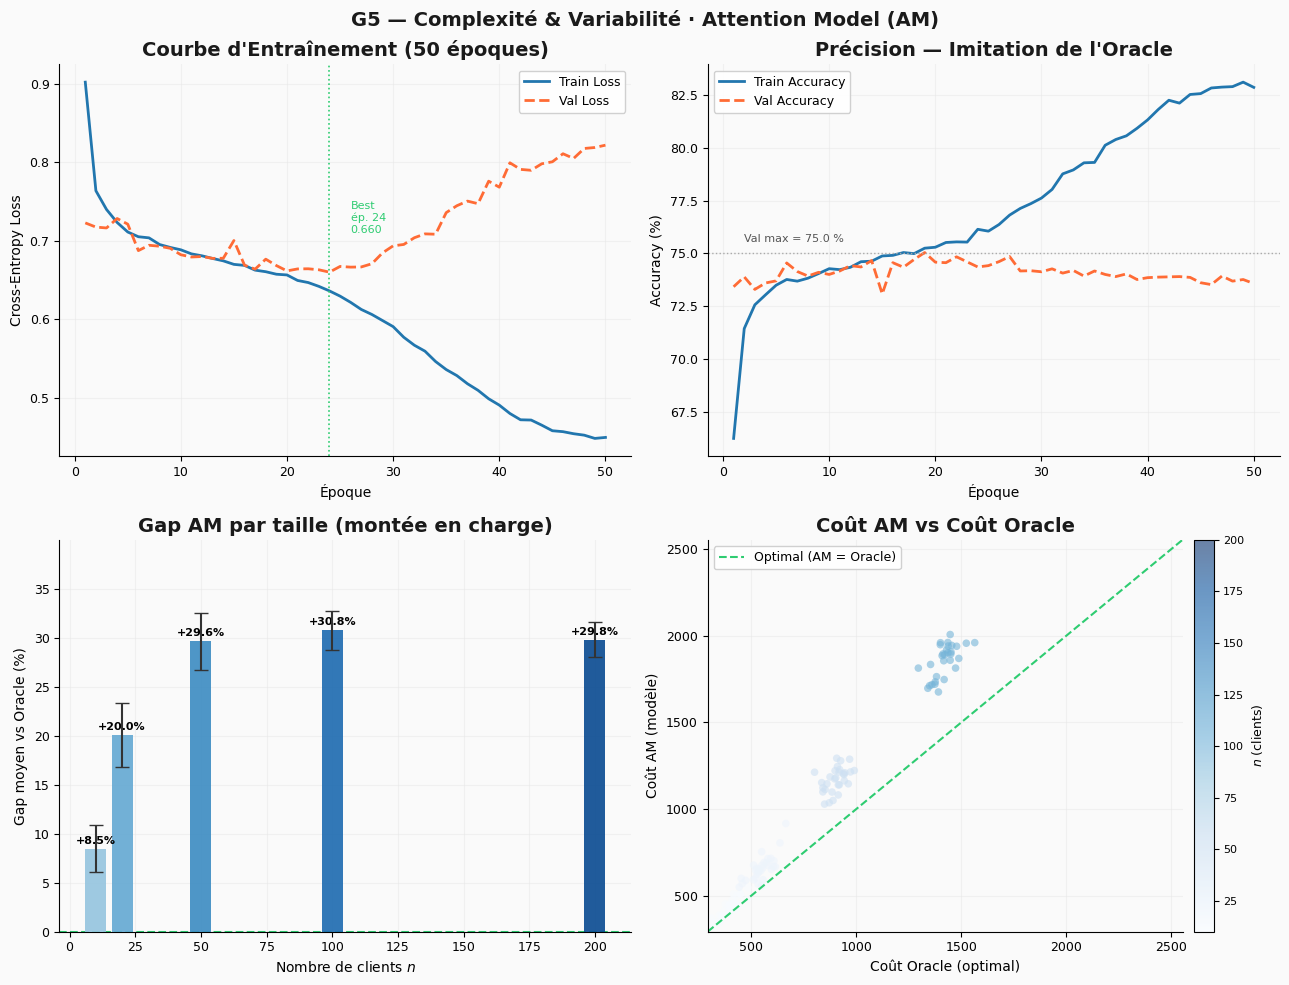

In [11]:
S = STYLE_CONFIG
fig, axes = plt.subplots(2, 2, figsize=S['figsize_quad'])
fig.patch.set_facecolor(S['couleur_fond'])

# ── [0,0] Courbe d'entraînement ──────────────────────────────────────────
ax = axes[0, 0]
epochs      = [e['epoch']      for e in history]
train_loss  = [e['train_loss'] for e in history]
val_loss    = [e['val_loss']   for e in history]
train_acc   = [e['train_acc']  for e in history]
val_acc     = [e['val_acc']    for e in history]

ax.plot(epochs, train_loss, color=S['couleur_primaire'],
        linewidth=S['linewidth'], label='Train Loss')
ax.plot(epochs, val_loss, color=S['couleur_alt'],
        linewidth=S['linewidth'], linestyle='--', label='Val Loss')
# Annotation meilleure époque
best_epoch = epochs[np.argmin(val_loss)]
best_val   = min(val_loss)
ax.axvline(best_epoch, color=S['couleur_oracle'], linewidth=1.2, linestyle=':')
ax.annotate(f'Best\nép. {best_epoch}\n{best_val:.3f}',
            xy=(best_epoch, best_val), xytext=(best_epoch + 2, best_val + 0.05),
            fontsize=8, color=S['couleur_oracle'])
apply_style(ax, title='Courbe d\'Entraînement (50 époques)',
            xlabel='Époque', ylabel='Cross-Entropy Loss')

# ── [0,1] Précision train vs val ─────────────────────────────────────────
ax = axes[0, 1]
ax.plot(epochs, [a * 100 for a in train_acc], color=S['couleur_primaire'],
        linewidth=S['linewidth'], label='Train Accuracy')
ax.plot(epochs, [a * 100 for a in val_acc], color=S['couleur_alt'],
        linewidth=S['linewidth'], linestyle='--', label='Val Accuracy')
ax.axhline(max(val_acc) * 100, color='#aaa', linewidth=1, linestyle=':')
ax.text(2, max(val_acc) * 100 + 0.5,
        f'Val max = {max(val_acc)*100:.1f} %', fontsize=8, color='#555')
apply_style(ax, title='Précision — Imitation de l\'Oracle',
            xlabel='Époque', ylabel='Accuracy (%)')

# ── [1,0] Gap moyen par taille (montée en charge) ─────────────────────
ax = axes[1, 0]
colors_n = plt.cm.Blues(np.linspace(0.4, 0.9, len(TAILLES)))
bars = ax.bar(TAILLES, means_g, color=colors_n, alpha=0.9, width=8, zorder=3)
ax.errorbar(TAILLES, means_g, yerr=[err_lo, err_hi],
            fmt='none', color='#333', capsize=5, linewidth=1.5, zorder=4)
for rect, val in zip(bars, means_g):
    ax.text(rect.get_x() + rect.get_width() / 2, rect.get_height() + 0.3,
            f'+{val:.1f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')
ax.axhline(0, color=S['couleur_oracle'], linewidth=1.5, linestyle='--')
apply_style(ax, title='Gap AM par taille (montée en charge)',
            xlabel='Nombre de clients $n$',
            ylabel='Gap moyen vs Oracle (%)', legend=False)
ax.set_ylim(0, max(means_g) * 1.3)

# ── [1,1] Scatter coût AM vs Oracle ──────────────────────────────────────
ax = axes[1, 1]
cmap = plt.cm.Blues
norm = plt.Normalize(min(TAILLES), max(TAILLES))
for n in TAILLES:
    sub = df[df['n'] == n]
    sc  = ax.scatter(sub['cout_oracle'], sub['cout_am'],
                     c=[n] * len(sub), cmap=cmap, norm=norm,
                     alpha=0.6, s=30, edgecolors='none')
# Droite y=x (performance parfaite)
lims = [df['cout_oracle'].min() * 0.95, df['cout_oracle'].max() * 1.05]
ax.plot(lims, lims, color=S['couleur_oracle'], linewidth=1.5,
        linestyle='--', label='Optimal (AM = Oracle)')
cb = fig.colorbar(sc, ax=ax, pad=0.02)
cb.set_label('$n$ (clients)', fontsize=9)
cb.ax.tick_params(labelsize=8)
ax.set_xlim(lims); ax.set_ylim(lims)
apply_style(ax, title='Coût AM vs Coût Oracle',
            xlabel='Coût Oracle (optimal)', ylabel='Coût AM (modèle)')

fig.suptitle(f'G5 — Complexité & Variabilité · {NOM}', **S['font_titre'])
plt.tight_layout()
save_fig(fig, 'G5_complexite_variabilite.png')

---
## 7. Synthèse

### Tableau de performances

In [12]:
print(f'{'n':>6} | {'Coût AM moy':>12} | {'Oracle moy':>11} | {'Gap moy':>9} | {'Gap std':>8} | {'Temps (ms)':>11}')
print('-' * 68)
for i, n in enumerate(TAILLES):
    sub    = df[df['n'] == n]
    c_am   = sub['cout_am'].mean()
    c_or   = sub['cout_oracle'].mean()
    g_moy  = sub['gap_pct'].mean()
    g_std  = sub['gap_pct'].std()
    t_ms   = np.mean(temps_par_taille[n]) * 1000
    print(f'{n:>6} | {c_am:>12.1f} | {c_or:>11.1f} | {g_moy:>+8.1f}% | {g_std:>7.1f}% | {t_ms:>10.1f} ms')

     n |  Coût AM moy |  Oracle moy |   Gap moy |  Gap std |  Temps (ms)
--------------------------------------------------------------------
    10 |        431.6 |       397.8 |     +8.5% |     6.4% |       23.6 ms
    20 |        658.3 |       549.0 |    +20.0% |     8.8% |       51.5 ms
    50 |       1169.3 |       903.0 |    +29.6% |     7.7% |      124.7 ms
   100 |       1856.9 |      1420.4 |    +30.8% |     5.3% |      265.6 ms
   200 |       3032.8 |      2337.3 |    +29.8% |     4.7% |      616.2 ms


### Points forts de l'Attention Model

- **100 % de faisabilité** — le masquage contraint garantit l'absence de violation
- **Inférence quasi-linéaire** — quelques dizaines de ms même pour $n=200$
- **Gap raisonnable sur n=10** — environ +8 % vs oracle (vs +100 % pour une heuristique naïve)
- **Généralisation** — le modèle entraîné sur $n=10$ produit des solutions valides pour $n=200$

### Limites

- **Gap qui croît avec $n$** — +8 % pour $n=10$, +30 % pour $n=100/200$
  → le modèle entraîné sur petites instances ne capture pas les patterns de grande taille
- **Apprentissage par imitation** — limité par la qualité des décisions de l'oracle
  (distribution shift lors de l'inférence)
- **Sensibilité à la distribution** — performances dégradées sur des instances
  structurellement différentes des instances d'entraînement

### Pistes d'amélioration

| Amélioration | Impact attendu |
|--|--|
| Entraîner sur toutes les tailles | Réduire gap pour $n > 10$ |
| Reinforcement Learning (REINFORCE) | Surpasser l'oracle par auto-amélioration |
| Beam search au décodage | Réduire gap de 5-10 % sans ré-entraînement |
| Augmentation des données | Meilleure généralisation |

---
*Livrable 2 — Recherche Opérationnelle · Phase 4 · Attention Model (AM)*